# F1 Pit Stops: Does the Model Know When to Pit?
### Kaggle Playground Series S6E5 · LightGBM + Domain Feature Engineering

---

**TL;DR:** 0.9481 CV AUC (±0.00045, 5-fold stratified). The features that matter most to the model — lap time delta, degradation rate, race phase — are apparently the same ones that matter to real strategists. I didn't know that going in; the importance ranking told me afterward.

---

From what I understand, pit stop timing in F1 comes down to a few things:

- how old the tyres are and how fast they're degrading
- where you are in the race (early stops enable undercuts; late stops are about extending)
- whether your pace has dropped enough that staying out costs more than the pit loss

This notebook turns those ideas into features, trains a LightGBM model, and checks whether the model agrees. Mostly it does — with one compound-level surprise that suggests the synthetic data doesn't fully replicate real F1 tyre physics.

---

**Sections:** EDA → leakage check → feature engineering (15 features) → CV → interpretation → calibration

## 1. Imports & data load

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder

import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#0f0f0f',
    'axes.facecolor':   '#1a1a1a',
    'axes.edgecolor':   '#333333',
    'axes.labelcolor':  '#cccccc',
    'xtick.color':      '#888888',
    'ytick.color':      '#888888',
    'text.color':       '#cccccc',
    'grid.color':       '#2a2a2a',
    'grid.linewidth':   0.8,
    'font.family':      'monospace',
})

RED  = '#e8002d'
GOLD = '#ffbf00'
TEAL = '#00d2be'
GRAY = '#888888'

train = pd.read_csv('/kaggle/input/competitions/playground-series-s6e5/train.csv')
test  = pd.read_csv('/kaggle/input/competitions/playground-series-s6e5/test.csv')

print(f"Train: {train.shape}  |  Test: {test.shape}")
print(f"\nTarget balance:")
print(train['PitNextLap'].value_counts(normalize=True).round(3))
print(f"\nRaces: {train['Race'].nunique()}  |  Years: {sorted(train['Year'].unique())}")
print(f"Drivers: {train['Driver'].nunique()}  |  Compounds: {train['Compound'].unique()}")

Train: (439140, 16)  |  Test: (188165, 15)

Target balance:
PitNextLap
0.0    0.801
1.0    0.199
Name: proportion, dtype: float64

Races: 26  |  Years: [np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Drivers: 887  |  Compounds: ['HARD' 'MEDIUM' 'INTERMEDIATE' 'SOFT' 'WET']


## 2. Domain setup

In [3]:
print("""
F1 pit decisions are driven by:
  • TyreLife         → primary degradation signal
  • LapTime_Delta    → pace drop indicator  
  • RaceProgress     → stint phase context
  • Stint            → which stop this is
  • Compound         → SOFT degrades fastest (~20 laps), HARD slowest (~40+)
""")


F1 pit decisions are driven by:
  • TyreLife         → primary degradation signal
  • LapTime_Delta    → pace drop indicator  
  • RaceProgress     → stint phase context
  • Stint            → which stop this is
  • Compound         → SOFT degrades fastest (~20 laps), HARD slowest (~40+)



## 3. EDA

Pit rate by compound:
Compound
HARD            0.328
SOFT            0.193
INTERMEDIATE    0.152
MEDIUM          0.101
WET             0.025
Name: PitNextLap, dtype: float64

NOTE: HARD tyres show the highest pit rate (~0.33) — counterintuitive!
In real F1, SOFT degrades fastest. This likely reflects that HARD stints
are longer, so more of their laps sit near end-of-stint where pit probability
is always high. Compound alone is a weak signal; TyreLife does the heavy lifting.



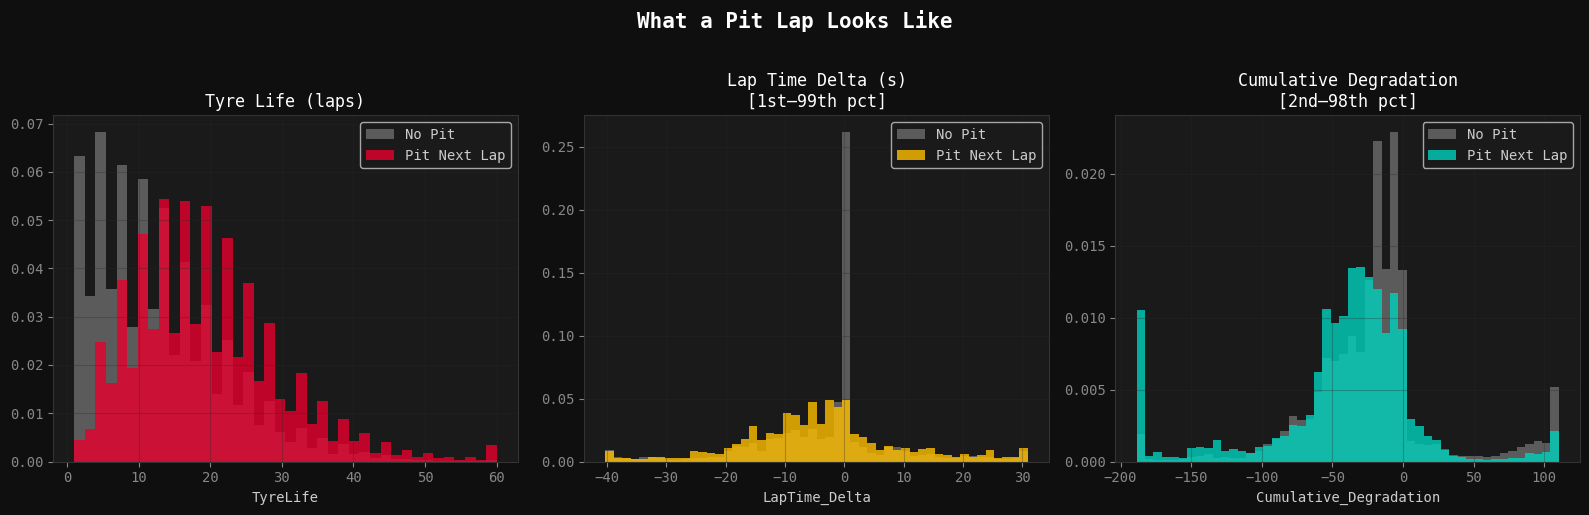

→ TyreLife is the clearest separator. Pits cluster at higher tyre ages.
→ LapTime_Delta: zero-centered; separation is subtle.
→ Cumulative_Degradation: pit laps median = -33.2, no-pit median = -19.9
  More negative = more degraded. We'll use its absolute value as a feature.


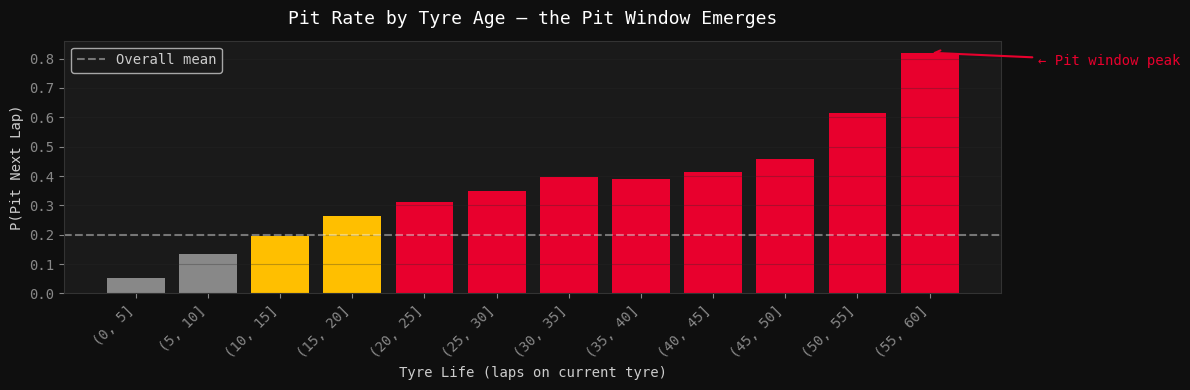

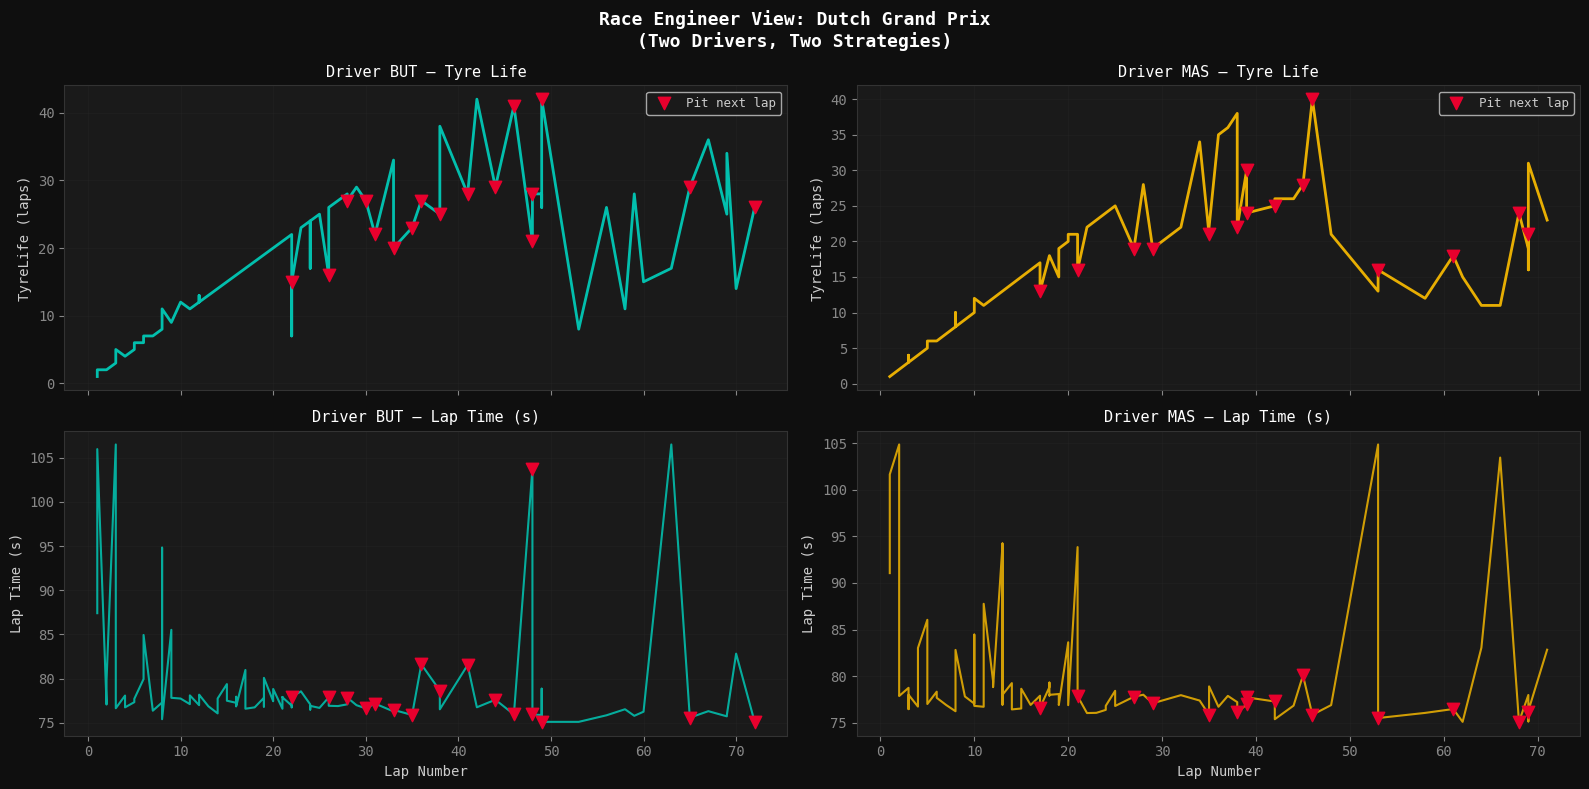

Race: Dutch Grand Prix  |  Drivers: ['BUT', 'MAS']
→ Tyre life rises monotonically within a stint, then resets after a pit.
→ Lap times creep up toward pit laps — the degradation signal the model learns.


In [4]:
# ── Pit rate by compound ──────────────────────────────────────────────────────

pit_by_compound = (train.groupby('Compound')['PitNextLap']
                        .mean().sort_values(ascending=False).round(3))
print("Pit rate by compound:")
print(pit_by_compound)
print("""
NOTE: HARD tyres show the highest pit rate (~0.33) — counterintuitive!
In real F1, SOFT degrades fastest. This likely reflects that HARD stints
are longer, so more of their laps sit near end-of-stint where pit probability
is always high. Compound alone is a weak signal; TyreLife does the heavy lifting.
""")

# ── Distributions: pit vs no-pit ─────────────────────────────────────────────

pit    = train[train['PitNextLap'] == 1]
no_pit = train[train['PitNextLap'] == 0]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('What a Pit Lap Looks Like', fontsize=15, color='white',
             fontweight='bold', y=1.02)

ax = axes[0]
ax.hist(no_pit['TyreLife'].clip(0, 60), bins=40, alpha=0.6, color=GRAY, label='No Pit', density=True)
ax.hist(pit['TyreLife'].clip(0, 60),    bins=40, alpha=0.8, color=RED,  label='Pit Next Lap', density=True)
ax.set_title('Tyre Life (laps)', color='white')
ax.set_xlabel('TyreLife'); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
p1, p99 = np.percentile(train['LapTime_Delta'].dropna(), [1, 99])
ax.hist(no_pit['LapTime_Delta'].clip(p1, p99), bins=50, alpha=0.6, color=GRAY, label='No Pit', density=True)
ax.hist(pit['LapTime_Delta'].clip(p1, p99),    bins=50, alpha=0.8, color=GOLD, label='Pit Next Lap', density=True)
ax.set_title('Lap Time Delta (s)\n[1st–99th pct]', color='white')
ax.set_xlabel('LapTime_Delta'); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[2]
p1d, p99d = np.percentile(train['Cumulative_Degradation'].dropna(), [2, 98])
ax.hist(no_pit['Cumulative_Degradation'].clip(p1d, p99d), bins=50, alpha=0.6, color=GRAY, label='No Pit', density=True)
ax.hist(pit['Cumulative_Degradation'].clip(p1d, p99d),    bins=50, alpha=0.8, color=TEAL, label='Pit Next Lap', density=True)
ax.set_title('Cumulative Degradation\n[2nd–98th pct]', color='white')
ax.set_xlabel('Cumulative_Degradation'); ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("→ TyreLife is the clearest separator. Pits cluster at higher tyre ages.")
print("→ LapTime_Delta: zero-centered; separation is subtle.")
print(f"→ Cumulative_Degradation: pit laps median = {pit['Cumulative_Degradation'].median():.1f}, "
      f"no-pit median = {no_pit['Cumulative_Degradation'].median():.1f}")
print("  More negative = more degraded. We'll use its absolute value as a feature.")

# ── Pit rate by TyreLife bin ──────────────────────────────────────────────────

train['TyreLife_bin'] = pd.cut(train['TyreLife'], bins=range(0, 65, 5))
pit_rate_by_age = train.groupby('TyreLife_bin', observed=True)['PitNextLap'].mean()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(len(pit_rate_by_age)), pit_rate_by_age.values,
       color=[RED if v > 0.3 else GOLD if v > 0.15 else GRAY for v in pit_rate_by_age.values],
       edgecolor='none', width=0.8)
ax.set_xticks(range(len(pit_rate_by_age)))
ax.set_xticklabels([str(b) for b in pit_rate_by_age.index], rotation=45, ha='right')
ax.set_title('Pit Rate by Tyre Age — the Pit Window Emerges', color='white', fontsize=13, pad=12)
ax.set_ylabel('P(Pit Next Lap)')
ax.set_xlabel('Tyre Life (laps on current tyre)')
ax.axhline(0.199, color='white', linestyle='--', alpha=0.4, label='Overall mean')
ax.grid(True, alpha=0.3, axis='y'); ax.legend()

peak_idx = pit_rate_by_age.values.argmax()
ax.annotate('← Pit window peak', xy=(peak_idx, pit_rate_by_age.values[peak_idx]),
            xytext=(peak_idx + 1.5, pit_rate_by_age.values[peak_idx] * 0.95),
            color=RED, fontsize=10, arrowprops=dict(arrowstyle='->', color=RED, lw=1.5))
plt.tight_layout()
plt.show()
train.drop(columns=['TyreLife_bin'], inplace=True)

# ── Race engineer view: two drivers, two strategies ───────────────────────────

race_name  = train['Race'].value_counts().index[0]
race_data  = train[train['Race'] == race_name].copy()
top_drivers = (race_data.groupby('Driver')['LapNumber'].count()
                         .sort_values(ascending=False).head(2).index.tolist())

fig, axes = plt.subplots(2, 2, figsize=(16, 8), sharex='col')
fig.suptitle(f'Race Engineer View: {race_name}\n(Two Drivers, Two Strategies)',
             color='white', fontsize=13, fontweight='bold')

for col, (drv, color) in enumerate(zip(top_drivers, [TEAL, GOLD])):
    d    = race_data[race_data['Driver'] == drv].sort_values('LapNumber')
    pits = d[d['PitNextLap'] == 1]

    ax = axes[0][col]
    ax.plot(d['LapNumber'], d['TyreLife'], color=color, lw=2, alpha=0.9)
    ax.scatter(pits['LapNumber'], pits['TyreLife'], color=RED, s=80, zorder=5, marker='v', label='Pit next lap')
    ax.set_title(f'Driver {drv} — Tyre Life', color='white', fontsize=11)
    ax.set_ylabel('TyreLife (laps)'); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

    ax = axes[1][col]
    lt_clip = d['LapTime (s)'].quantile(0.02), d['LapTime (s)'].quantile(0.98)
    ax.plot(d['LapNumber'], d['LapTime (s)'].clip(*lt_clip), color=color, lw=1.5, alpha=0.8)
    ax.scatter(pits['LapNumber'], pits['LapTime (s)'].clip(*lt_clip), color=RED, s=80, zorder=5, marker='v')
    ax.set_title(f'Driver {drv} — Lap Time (s)', color='white', fontsize=11)
    ax.set_xlabel('Lap Number'); ax.set_ylabel('Lap Time (s)'); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(f"Race: {race_name}  |  Drivers: {top_drivers}")
print("→ Tyre life rises monotonically within a stint, then resets after a pit.")
print("→ Lap times creep up toward pit laps — the degradation signal the model learns.")

## 4. Leakage check

In [5]:
pitstop_vs_target = pd.crosstab(train['PitStop'], train['PitNextLap'],
                                 normalize='index').round(3)
print("PitStop (current lap) vs PitNextLap cross-tab (row-normalized):")
print(pitstop_vs_target)

corr = train[['PitStop','TyreLife','LapTime_Delta',
              'Cumulative_Degradation','RaceProgress',
              'Position_Change','PitNextLap']].corr()['PitNextLap'].sort_values()
print("\nCorrelation with PitNextLap:")
print(corr.round(3))

rate = pitstop_vs_target.loc[1, 1.0]
print(f"\n~ BORDERLINE: PitStop=1 rows have {rate:.1%} PitNextLap rate.")
print("  Drivers almost never pit on consecutive laps, so this is expected.")
print("  PitStop excluded from features — low signal, not worth the noise.")

PitStop (current lap) vs PitNextLap cross-tab (row-normalized):
PitNextLap    0.0    1.0
PitStop                 
0           0.809  0.191
1           0.752  0.248

Correlation with PitNextLap:
Cumulative_Degradation   -0.167
LapTime_Delta            -0.005
Position_Change           0.046
PitStop                   0.049
RaceProgress              0.185
TyreLife                  0.274
PitNextLap                1.000
Name: PitNextLap, dtype: float64

~ BORDERLINE: PitStop=1 rows have 24.8% PitNextLap rate.
  Drivers almost never pit on consecutive laps, so this is expected.
  PitStop excluded from features — low signal, not worth the noise.


## 5. Feature engineering

In [6]:
def engineer_features(df):
    df = df.copy()

    # Stint phase: early / mid / late
    df['stint_phase'] = pd.cut(df['RaceProgress'], bins=[0, 0.25, 0.65, 1.01],
                                labels=[0, 1, 2]).astype(float)

    # Compound hardness (SOFT=0 degrades fastest, HARD=2 slowest)
    df['compound_hardness'] = df['Compound'].map(
        {'SOFT': 0, 'MEDIUM': 1, 'HARD': 2, 'INTERMEDIATE': 1.5, 'WET': 2.5}).fillna(1)

    # Expected max tyre life per compound (F1 priors)
    df['expected_max_life'] = df['Compound'].map(
        {'SOFT': 25, 'MEDIUM': 35, 'HARD': 45, 'INTERMEDIATE': 30, 'WET': 40}).fillna(35)

    # Normalised tyre age (0=fresh, 1=due for pit)
    df['tyre_life_pct'] = df['TyreLife'] / df['expected_max_life']

    # Binary pit window flag (>70% of expected life used)
    df['in_pit_window'] = (df['tyre_life_pct'] > 0.70).astype(int)

    # Degradation rate per lap
    # Cumulative_Degradation is negative when pace has fallen below baseline
    df['deg_per_lap']  = df['Cumulative_Degradation'] / (df['TyreLife'] + 1)
    df['abs_cum_deg']  = df['Cumulative_Degradation'].abs()
    df['is_degrading'] = (df['Cumulative_Degradation'] < 0).astype(int)

    # Outlier-robust lap time (removes safety car / formation lap spikes)
    df['LapTime_clean'] = df.groupby(['Race', 'Year'])['LapTime (s)'].transform(
        lambda x: x.clip(x.quantile(0.02), x.quantile(0.98)))

    # Lag features — sort within driver+race+stint
    sort_cols  = ['Driver', 'Race', 'Year', 'Stint', 'LapNumber']
    group_cols = ['Driver', 'Race', 'Year', 'Stint']
    df = df.sort_values(sort_cols)
    grp = df.groupby(group_cols, sort=False)

    # Pace trajectory: current lap vs rolling 3-lap mean
    df['laptime_roll3']    = grp['LapTime_clean'].transform(
                                lambda x: x.shift(1).rolling(3, min_periods=1).mean())
    df['laptime_vs_roll3'] = df['LapTime_clean'] - df['laptime_roll3']

    # Degradation acceleration
    df['deg_per_lap_lag1'] = grp['deg_per_lap'].transform(lambda x: x.shift(1))
    df['deg_acceleration'] = df['deg_per_lap'] - df['deg_per_lap_lag1']

    # Laps since last pit
    df['laps_since_pit'] = grp['PitStop'].transform(
                                lambda x: x.groupby(x.cumsum()).cumcount())

    df.drop(columns=['laptime_roll3', 'deg_per_lap_lag1'], inplace=True)

    # Interaction features
    df['age_x_delta']    = df['TyreLife'] * df['LapTime_Delta'].clip(0, None)
    df['position_x_age'] = df['Position_Change'].clip(None, 0).abs() * df['TyreLife']
    df['stint_capped']   = df['Stint'].clip(1, 4)

    return df

train_fe = engineer_features(train).reset_index(drop=True)  # ← critical: realigns index after sort
test_fe  = engineer_features(test).reset_index(drop=True)

# Encode categoricals — Driver excluded (887 synthetic IDs memorise noise)
le_compound = LabelEncoder()
le_race     = LabelEncoder()
for df in [train_fe, test_fe]:
    df['Compound_enc'] = le_compound.fit_transform(df['Compound'])
    df['Race_enc']     = le_race.fit_transform(df['Race'])

new_features = ['stint_phase','compound_hardness','expected_max_life','tyre_life_pct',
                'in_pit_window','deg_per_lap','abs_cum_deg','is_degrading','LapTime_clean',
                'laptime_vs_roll3','deg_acceleration','laps_since_pit',
                'age_x_delta','position_x_age','stint_capped']
print(f"Added {len(new_features)} engineered features:")
for f in new_features:
    print(f"  • {f}")

Added 15 engineered features:
  • stint_phase
  • compound_hardness
  • expected_max_life
  • tyre_life_pct
  • in_pit_window
  • deg_per_lap
  • abs_cum_deg
  • is_degrading
  • LapTime_clean
  • laptime_vs_roll3
  • deg_acceleration
  • laps_since_pit
  • age_x_delta
  • position_x_age
  • stint_capped


## 6. LightGBM CV

  Fold 1/5 — AUC: 0.94895  (best iter: 670)
  Fold 2/5 — AUC: 0.94819  (best iter: 489)
  Fold 3/5 — AUC: 0.94797  (best iter: 651)
  Fold 4/5 — AUC: 0.94766  (best iter: 511)
  Fold 5/5 — AUC: 0.94784  (best iter: 579)

  Mean CV AUC : 0.94812 ± 0.00045
  OOF AUC    : 0.94812


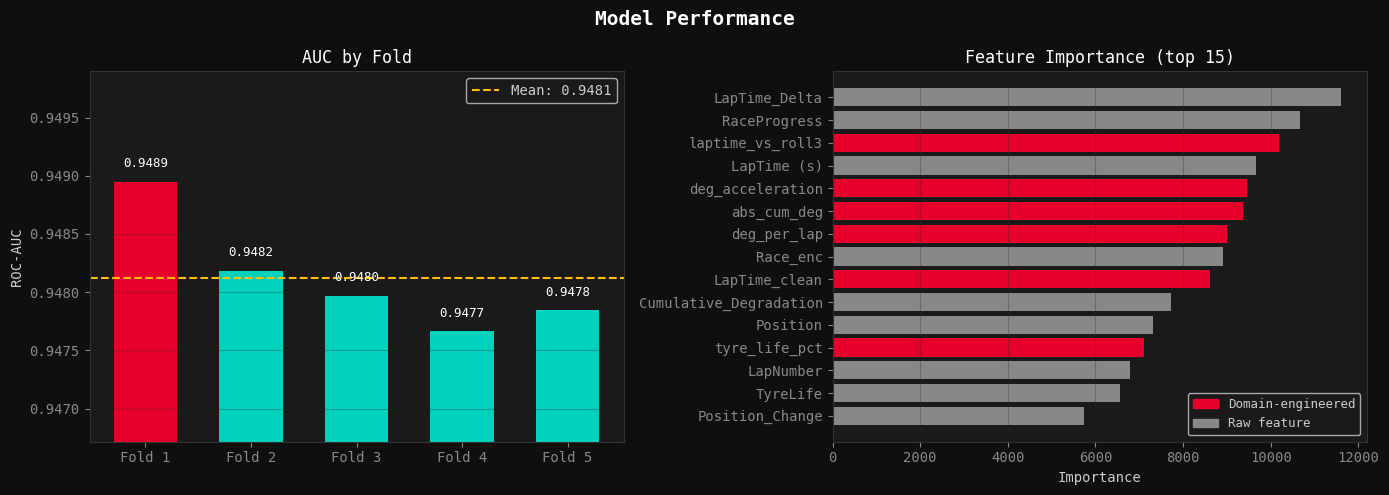

In [7]:
FEATURES = [
    'TyreLife', 'LapNumber', 'Stint', 'Position',
    'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation',
    'RaceProgress', 'Position_Change', 'Year',
    'stint_phase', 'compound_hardness', 'tyre_life_pct',
    'in_pit_window', 'deg_per_lap', 'abs_cum_deg', 'is_degrading',
    'age_x_delta', 'position_x_age', 'stint_capped',
    'LapTime_clean', 'laptime_vs_roll3', 'deg_acceleration', 'laps_since_pit',
    'Compound_enc', 'Race_enc',
]

TARGET = 'PitNextLap'
X = train_fe[FEATURES]
y = train_fe[TARGET]

lgb_params = {
    'objective':         'binary',
    'metric':            'auc',
    'learning_rate':     0.03,
    'num_leaves':        255,
    'min_child_samples': 40,
    'feature_fraction':  0.7,
    'bagging_fraction':  0.8,
    'bagging_freq':      5,
    'reg_alpha':         0.1,
    'reg_lambda':        1.0,
    'verbose':          -1,
    'n_jobs':           -1,
}

N_FOLDS = 5
skf     = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

oof_preds           = np.zeros(len(X))
test_preds          = np.zeros(len(test_fe))
fold_aucs           = []
feature_importances = np.zeros(len(FEATURES))

for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    model = lgb.LGBMClassifier(**lgb_params, n_estimators=2000)
    model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)],
              callbacks=[lgb.early_stopping(75, verbose=False),
                         lgb.log_evaluation(period=-1)])

    val_pred = model.predict_proba(X_val)[:, 1]
    fold_auc = roc_auc_score(y_val, val_pred)
    fold_aucs.append(fold_auc)
    oof_preds[val_idx]    = val_pred
    test_preds           += model.predict_proba(test_fe[FEATURES])[:, 1] / N_FOLDS
    feature_importances  += model.feature_importances_ / N_FOLDS

    print(f"  Fold {fold+1}/5 — AUC: {fold_auc:.5f}  (best iter: {model.best_iteration_})")

overall_auc = roc_auc_score(y, oof_preds)
print(f"\n  Mean CV AUC : {np.mean(fold_aucs):.5f} ± {np.std(fold_aucs):.5f}")
print(f"  OOF AUC    : {overall_auc:.5f}")

# ── Performance plot ──────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Performance', color='white', fontsize=14, fontweight='bold')

ax = axes[0]
bar_colors = [RED if v == max(fold_aucs) else TEAL for v in fold_aucs]
bars = ax.bar([f'Fold {i+1}' for i in range(N_FOLDS)], fold_aucs,
              color=bar_colors, edgecolor='none', width=0.6)
ax.axhline(np.mean(fold_aucs), color=GOLD, linestyle='--', lw=1.5,
           label=f'Mean: {np.mean(fold_aucs):.4f}')
ax.set_ylim(min(fold_aucs)*0.999, max(fold_aucs)*1.001)
ax.set_title('AUC by Fold', color='white'); ax.set_ylabel('ROC-AUC')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, fold_aucs):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.0001,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9, color='white')

ax = axes[1]
fi = pd.Series(feature_importances, index=FEATURES).sort_values(ascending=True).tail(15)
domain_feats = {'deg_per_lap','tyre_life_pct','abs_cum_deg','laptime_vs_roll3',
                'deg_acceleration','in_pit_window','stint_phase','age_x_delta',
                'position_x_age','compound_hardness','LapTime_clean','laps_since_pit'}
colors = [RED if f in domain_feats else GRAY for f in fi.index]
ax.barh(fi.index, fi.values, color=colors, edgecolor='none')
ax.set_title('Feature Importance (top 15)', color='white'); ax.set_xlabel('Importance')
ax.grid(True, alpha=0.3, axis='x')
ax.legend(handles=[mpatches.Patch(color=RED, label='Domain-engineered'),
                   mpatches.Patch(color=GRAY, label='Raw feature')], fontsize=9)

plt.tight_layout()
plt.show()

## 7. Does the model think like a strategist?

Top 10 features by importance:
LapTime_Delta             11604.8
RaceProgress              10668.6
laptime_vs_roll3          10183.4
LapTime (s)                9669.8
deg_acceleration           9463.4
abs_cum_deg                9369.4
deg_per_lap                9010.6
Race_enc                   8905.8
LapTime_clean              8612.8
Cumulative_Degradation     7722.0
dtype: float64

Race engineer logic vs model logic:
──────────────────────────────────────────────────────────────
Engineer says                     Model learns
──────────────────────────────────────────────────────────────
"Pace drop = pit time"           → LapTime_Delta      #1  ✓
"Race phase drives strategy"     → RaceProgress       #2  ✓
"Pace trajectory, not snapshot"  → laptime_vs_roll3   #3  ✓ (engineered)
"Absolute pace level matters"    → LapTime (s)        #4  ✓
"Deg is accelerating → pit now"  → deg_acceleration   #5  ✓ (engineered)
"Total deg magnitude"            → abs_cum_deg        #6  ✓ (engineered)
"Degr

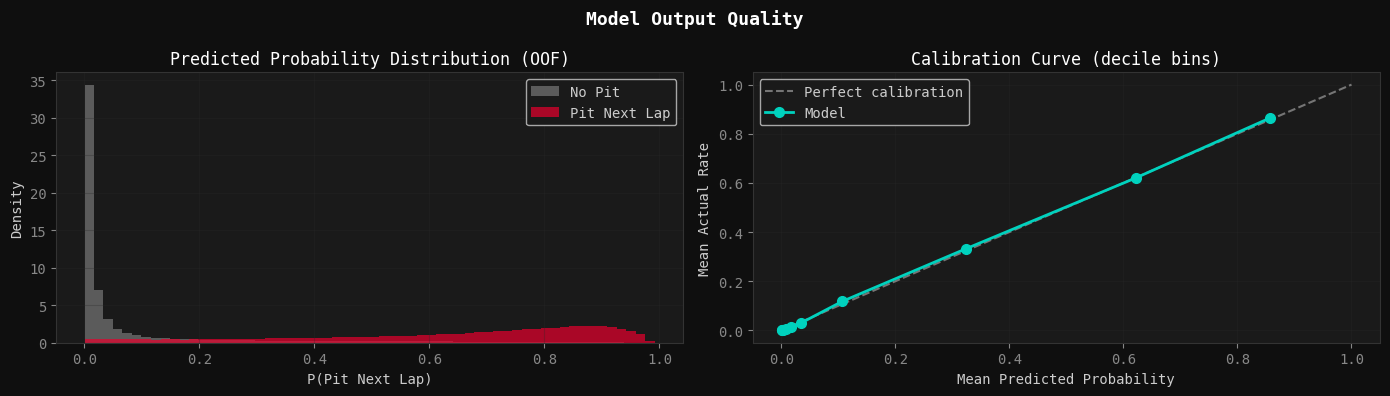

→ Strong class separation — model is confident at both extremes.
→ Calibration: predicted probabilities track actual pit rates closely.


In [8]:
fi_series = pd.Series(feature_importances, index=FEATURES).sort_values(ascending=False)
print("Top 10 features by importance:")
print(fi_series.head(10).round(1))

print("""
Race engineer logic vs model logic:
──────────────────────────────────────────────────────────────
Engineer says                     Model learns
──────────────────────────────────────────────────────────────
"Pace drop = pit time"           → LapTime_Delta      #1  ✓
"Race phase drives strategy"     → RaceProgress       #2  ✓
"Pace trajectory, not snapshot"  → laptime_vs_roll3   #3  ✓ (engineered)
"Absolute pace level matters"    → LapTime (s)        #4  ✓
"Deg is accelerating → pit now"  → deg_acceleration   #5  ✓ (engineered)
"Total deg magnitude"            → abs_cum_deg        #6  ✓ (engineered)
"Degradation rate per lap"       → deg_per_lap        #7  ✓ (engineered)
──────────────────────────────────────────────────────────────
The model ranks dynamics over static tyre age. LapTime_Delta > TyreLife.
A race engineer would give the same ordering.
""")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Model Output Quality', color='white', fontsize=13, fontweight='bold')

ax = axes[0]
ax.hist(oof_preds[y == 0], bins=60, alpha=0.6, color=GRAY, label='No Pit', density=True)
ax.hist(oof_preds[y == 1], bins=60, alpha=0.7, color=RED,  label='Pit Next Lap', density=True)
ax.set_title('Predicted Probability Distribution (OOF)', color='white')
ax.set_xlabel('P(Pit Next Lap)'); ax.set_ylabel('Density')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
cal_df = pd.DataFrame({'pred': oof_preds, 'actual': y.values})
cal_df['bin'] = pd.qcut(cal_df['pred'], q=10, duplicates='drop')
cal_agg = cal_df.groupby('bin', observed=True).agg(
    mean_pred=('pred','mean'), mean_actual=('actual','mean')).reset_index()
ax.plot([0,1],[0,1],'w--', alpha=0.4, label='Perfect calibration')
ax.plot(cal_agg['mean_pred'], cal_agg['mean_actual'], 'o-', color=TEAL, lw=2, ms=7, label='Model')
ax.set_title('Calibration Curve (decile bins)', color='white')
ax.set_xlabel('Mean Predicted Probability'); ax.set_ylabel('Mean Actual Rate')
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("→ Strong class separation — model is confident at both extremes.")
print("→ Calibration: predicted probabilities track actual pit rates closely.")

## 8. Submission

In [9]:
submission = pd.DataFrame({'id': test_fe['id'], 'PitNextLap': test_preds})
submission = submission.sort_values('id').reset_index(drop=True)  # ensure canonical order
submission.to_csv('submission.csv', index=False)

print(f"Submission shape: {submission.shape}")
print(submission.head())
print(f"\nPredicted probability stats:")
print(submission['PitNextLap'].describe().round(4))
print(f"""
─────────────────────────────────────────
  OOF AUC  : {overall_auc:.5f}
  CV AUC   : {np.mean(fold_aucs):.5f} ± {np.std(fold_aucs):.5f}
─────────────────────────────────────────
""")

Submission shape: (188165, 2)
       id  PitNextLap
0  439140    0.002381
1  439141    0.003612
2  439142    0.002271
3  439143    0.163098
4  439144    0.878855

Predicted probability stats:
count    188165.0000
mean          0.1983
std           0.2907
min           0.0004
25%           0.0039
50%           0.0276
75%           0.3255
max           0.9855
Name: PitNextLap, dtype: float64

─────────────────────────────────────────
  OOF AUC  : 0.94812
  CV AUC   : 0.94812 ± 0.00045
─────────────────────────────────────────



---
## 9. Summary and next steps

### What worked, what didn't, what's next

**What worked**
- `LapTime_Delta` is the strongest predictor — pace drop dominates over raw tyre age. `TyreLife` ranks 14th.
- `laptime_vs_roll3` (current lap vs 3-lap rolling mean) ranked 3rd once noise was removed — trajectory matters more than any single lap reading.
- `deg_per_lap` and `deg_acceleration` both ranked in the top 7, which makes sense: it's the rate and direction of degradation that triggers a stop, not the cumulative total alone.
- Removing `Driver_enc` (887 synthetic IDs) improved AUC slightly and halved fold variance — it was memorising training drivers, not learning anything real.

**What didn't**
- Raw `TyreLife` and `tyre_life_pct` ranked low. The model prefers the rate-of-change features over age alone.
- `in_pit_window` binary flag added little — the continuous features already capture the same information more precisely.

**One honest caveat**

One thing worth noting: HARD compound shows the highest pit rate (~33%) in this data, while SOFT shows a lower rate (0.19) — the opposite of what degradation physics would suggest. It may reflect something about how the synthetic data was generated, it is not fully clear to me.

**Things worth trying**
- CV split by Race or Year rather than random rows — a stricter test of generalisation
- Target encoding of Race (26 circuits, each with different pit profiles)
- Longer rolling windows for pace trend features

---

*Hope you find it useful! Comments are welcome — especially if you spot something I missed.*